# 01 — Data Collection & Exploration
Downloads exchange rate data and performs initial EDA.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from ml.data_pipeline import download_all, load_all, summarize, run_pipeline

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

Matplotlib is building the font cache; this may take a moment.


## 1. Download Data

In [2]:
# Downloads and saves CSVs to data/raw/
raw_data = download_all()
summarize(raw_data)

2026-06-14 22:32:00,075 [INFO] Downloading EUR_USD (EURUSD=X)  2020-01-01 → 2026-06-10
2026-06-14 22:32:01,881 [INFO]   → 1675 rows  |  2020-01-01 to 2026-06-09
2026-06-14 22:32:01,904 [INFO]   Saved → D:\Projects\Research\data\raw\EUR_USD.csv
2026-06-14 22:32:01,904 [INFO] Downloading AUD_USD (AUDUSD=X)  2020-01-01 → 2026-06-10
2026-06-14 22:32:02,785 [INFO]   → 1675 rows  |  2020-01-01 to 2026-06-09
2026-06-14 22:32:02,811 [INFO]   Saved → D:\Projects\Research\data\raw\AUD_USD.csv
2026-06-14 22:32:02,811 [INFO] Downloading NZD_USD (NZDUSD=X)  2020-01-01 → 2026-06-10
2026-06-14 22:32:03,656 [INFO]   → 1675 rows  |  2020-01-01 to 2026-06-09
2026-06-14 22:32:03,679 [INFO]   Saved → D:\Projects\Research\data\raw\NZD_USD.csv
2026-06-14 22:32:03,679 [INFO] Download complete. 3/3 pairs fetched successfully.



Pair           Rows         Start           End   Missing Close
EUR_USD        1675    2020-01-01    2026-06-09               0
AUD_USD        1675    2020-01-01    2026-06-09               0
NZD_USD        1675    2020-01-01    2026-06-09               0



## 2. Plot Close Prices

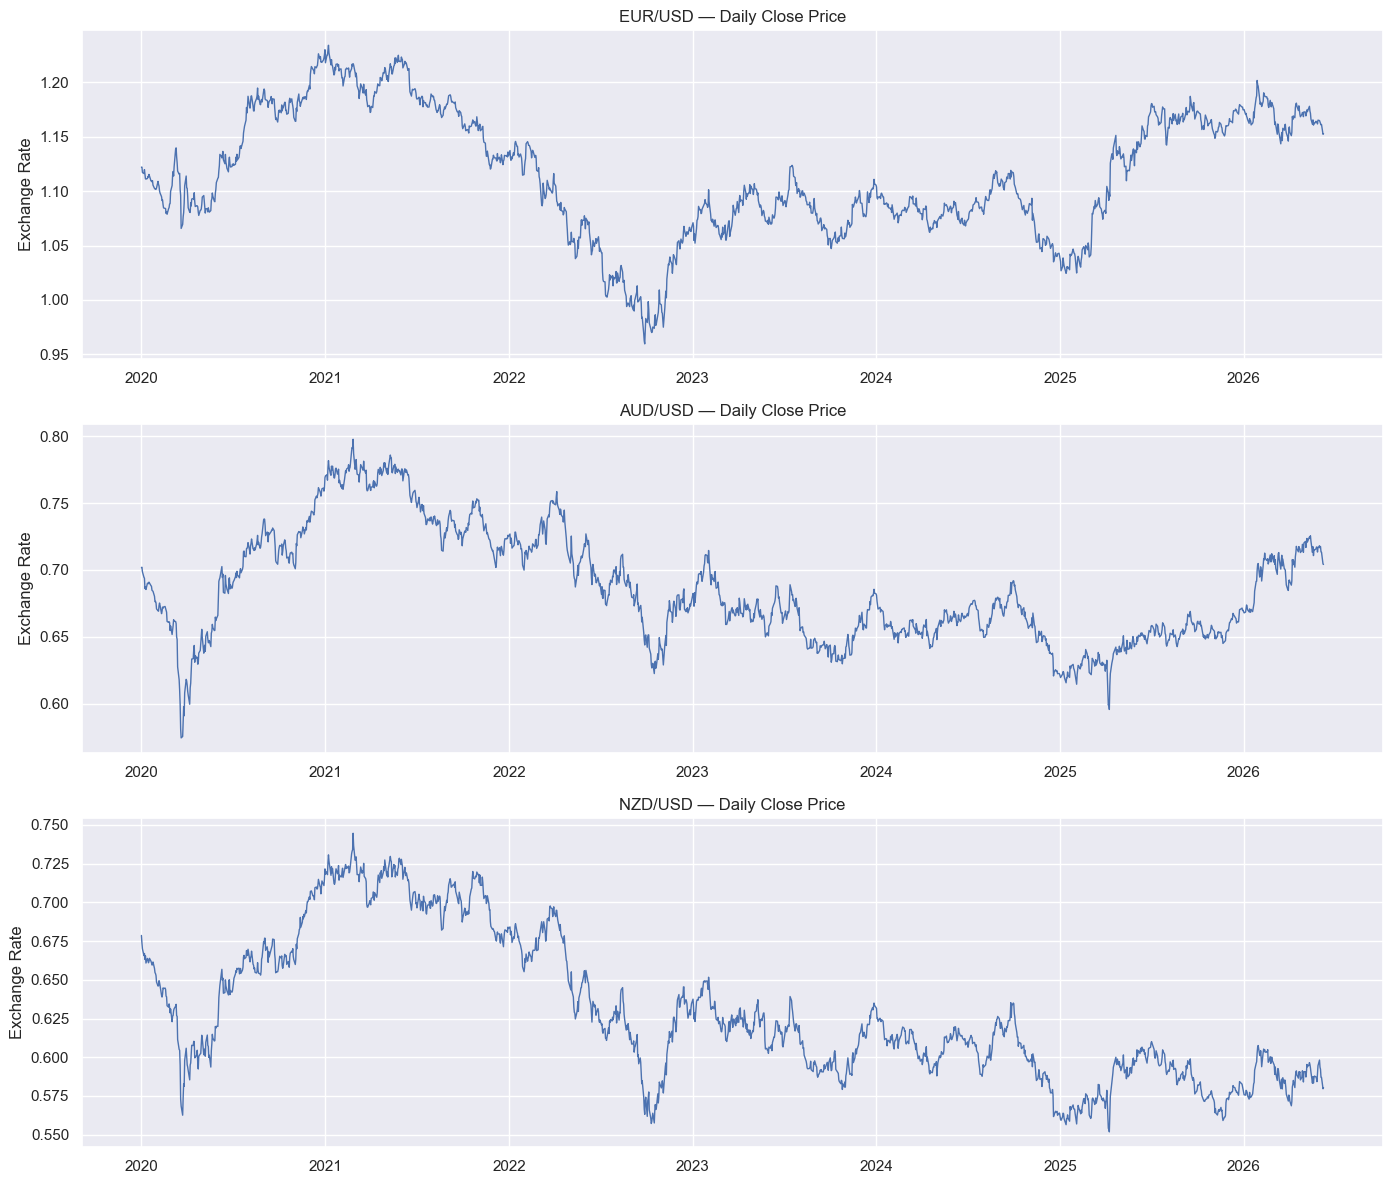

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, (name, df) in zip(axes, raw_data.items()):
    ax.plot(df['Date'], df['Close'], linewidth=1)
    ax.set_title(f'{name.replace("_", "/")} — Daily Close Price')
    ax.set_ylabel('Exchange Rate')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../data/processed/close_prices.png', dpi=150)
plt.show()

## 3. Run Preprocessing Pipeline

In [4]:
processed = {}
for name, df in raw_data.items():
    processed[name] = run_pipeline(df, pair_name=name, sequence_length=60)

print('Preprocessing complete.')
for name, p in processed.items():
    print(f'  {name}: X_train={p["X_train"].shape}, X_val={p["X_val"].shape}, X_test={p["X_test"].shape}')

2026-06-14 22:32:05,302 [INFO] Preprocessing EUR_USD
2026-06-14 22:32:05,311 [INFO]   Split → train=1340, val=167, test=168
2026-06-14 22:32:05,343 [INFO]   Sequences → train=(1220, 60, 7), val=(106, 60, 7), test=(107, 60, 7)
2026-06-14 22:32:05,376 [INFO]   Saved processed data → D:\Projects\Research\data\processed\EUR_USD
2026-06-14 22:32:05,376 [INFO] Preprocessing AUD_USD
2026-06-14 22:32:05,384 [INFO]   Split → train=1340, val=167, test=168
2026-06-14 22:32:05,399 [INFO]   Sequences → train=(1220, 60, 7), val=(106, 60, 7), test=(107, 60, 7)
2026-06-14 22:32:05,435 [INFO]   Saved processed data → D:\Projects\Research\data\processed\AUD_USD
2026-06-14 22:32:05,435 [INFO] Preprocessing NZD_USD
2026-06-14 22:32:05,447 [INFO]   Split → train=1340, val=167, test=168
2026-06-14 22:32:05,467 [INFO]   Sequences → train=(1220, 60, 7), val=(106, 60, 7), test=(107, 60, 7)
2026-06-14 22:32:05,499 [INFO]   Saved processed data → D:\Projects\Research\data\processed\NZD_USD


Preprocessing complete.
  EUR_USD: X_train=(1220, 60, 7), X_val=(106, 60, 7), X_test=(107, 60, 7)
  AUD_USD: X_train=(1220, 60, 7), X_val=(106, 60, 7), X_test=(107, 60, 7)
  NZD_USD: X_train=(1220, 60, 7), X_val=(106, 60, 7), X_test=(107, 60, 7)


## 4. Log Returns Distribution

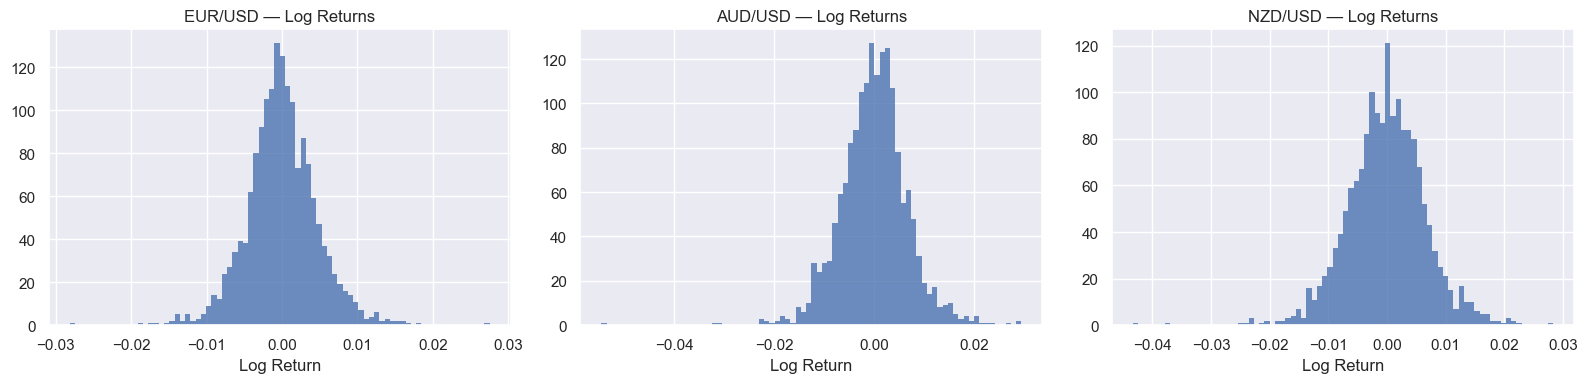

In [5]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, df) in zip(axes, raw_data.items()):
    log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()
    ax.hist(log_ret, bins=80, edgecolor='none', alpha=0.8)
    ax.set_title(f'{name.replace("_", "/")} — Log Returns')
    ax.set_xlabel('Log Return')
plt.tight_layout()
plt.show()

## 5. Correlation Between Pairs

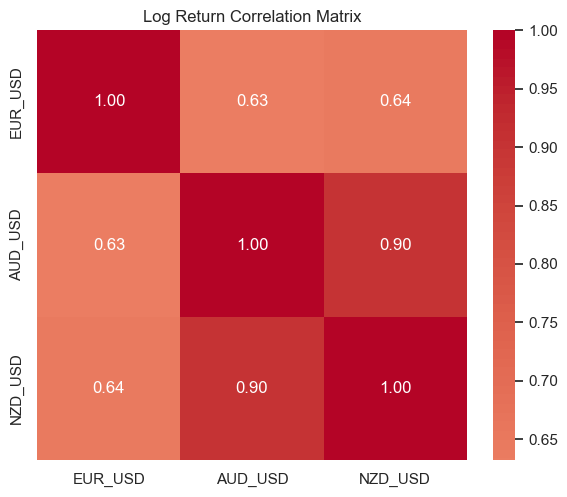

          EUR_USD   AUD_USD   NZD_USD
EUR_USD  1.000000  0.632339  0.643875
AUD_USD  0.632339  1.000000  0.901519
NZD_USD  0.643875  0.901519  1.000000


In [6]:
closes = pd.DataFrame({
    name: df.set_index('Date')['Close']
    for name, df in raw_data.items()
}).dropna()

log_returns = np.log(closes / closes.shift(1)).dropna()
corr = log_returns.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Log Return Correlation Matrix')
plt.tight_layout()
plt.show()
print(corr)